# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [3]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数（包含自适应参数）

In [81]:
instrument_id = '511090'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_adaptive',
    'stride': 1,

    'short_window': 60,
    'long_window': 300,
    'y_window': 300,

    'open_threshold': 2,  
    'open_confidence': 0,  
    'close_confidence': 1,  
    'standard_num': 1000,

    'atr_multiplier': 4,
    'vol_window': 900,

    'k_up': 3,
    'k_down': 3,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 获取交易日数据

In [26]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

# 方法1: 使用天数分割（原来的方法）
# train_dates, valid_dates, test_dates = split_dates(trade_dates,45,15,17)

# 方法2: 使用日期范围分割（新的灵活方法）
train_dates, valid_dates, test_dates = split_dates_by_range(
    trade_dates,
    train_start="20260101",  # 训练集开始日期
    train_end="20260228",    # 训练集结束日期
    valid_start="20251201",  # 验证集开始日期
    valid_end="20251201",    # 验证集结束日期
    test_start="20251201",   # 测试集开始日期
    test_end="20251231"      # 测试集结束日期
)

总交易日数量: 77
交易日范围: 20251201 ~ 20260327
训练集: 20260105 ~ 20260227 (34天)
验证集: 20251201 ~ 20251201 (1天)
测试集: 20251201 ~ 20251231 (23天)


## 生成训练数据

In [27]:
print("生成训练集样本...")
X_train, y_train , feature_names= samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")

生成训练集样本...
20260105: 产生 781 个样本
20260106: 产生 767 个样本
20260107: 产生 798 个样本
20260108: 产生 819 个样本
20260109: 产生 755 个样本
20260112: 产生 754 个样本
20260113: 产生 779 个样本
20260114: 产生 812 个样本
20260115: 产生 789 个样本
20260116: 产生 753 个样本
20260119: 产生 752 个样本
20260120: 产生 810 个样本
20260121: 产生 794 个样本
20260122: 产生 748 个样本
20260123: 产生 781 个样本
20260126: 产生 858 个样本
20260127: 产生 791 个样本
20260128: 产生 802 个样本
20260129: 产生 812 个样本
20260130: 产生 884 个样本
20260202: 产生 757 个样本
20260203: 产生 833 个样本
20260204: 产生 812 个样本
20260205: 产生 834 个样本
20260206: 产生 839 个样本
20260209: 产生 814 个样本
20260210: 产生 781 个样本
20260211: 产生 745 个样本
20260212: 产生 737 个样本
20260213: 产生 772 个样本
20260224: 产生 752 个样本
20260225: 产生 777 个样本
20260226: 产生 774 个样本
20260227: 产生 745 个样本
训练集样本: X=(26811, 12), y=(26811,)


In [28]:
print("生成验证集样本...")
X_valid, y_valid , __= samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")

生成验证集样本...
20251201: 产生 805 个样本
验证集样本: X=(805, 12), y=(805,)


In [29]:
print("生成测试集样本...")
X_test, y_test ,__= samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")

生成测试集样本...
20251201: 产生 805 个样本
20251202: 产生 794 个样本
20251203: 产生 791 个样本
20251204: 产生 778 个样本
20251205: 产生 813 个样本
20251208: 产生 803 个样本
20251209: 产生 858 个样本
20251210: 产生 754 个样本
20251211: 产生 807 个样本
20251212: 产生 766 个样本
20251215: 产生 809 个样本
20251216: 产生 865 个样本
20251217: 产生 808 个样本
20251218: 产生 787 个样本
20251219: 产生 769 个样本
20251222: 产生 821 个样本
20251223: 产生 857 个样本
20251224: 产生 803 个样本
20251225: 产生 821 个样本
20251226: 产生 822 个样本
20251229: 产生 821 个样本
20251230: 产生 799 个样本
20251231: 产生 794 个样本
测试集样本: X=(18545, 12), y=(18545,)


## 训练模型

In [30]:
model = train_model(X_train, y_train, X_valid, y_valid, param_dict , feature_names)

训练 xgboost 模型...
[0]	validation_0-logloss:0.63961
[100]	validation_0-logloss:0.59892
[200]	validation_0-logloss:0.58331
[300]	validation_0-logloss:0.57704
[400]	validation_0-logloss:0.57490
[500]	validation_0-logloss:0.57333
[600]	validation_0-logloss:0.57302
[700]	validation_0-logloss:0.57266
[800]	validation_0-logloss:0.57256
[900]	validation_0-logloss:0.57244
[1000]	validation_0-logloss:0.57205
[1100]	validation_0-logloss:0.57162
[1200]	validation_0-logloss:0.57160
[1300]	validation_0-logloss:0.57210
[1400]	validation_0-logloss:0.57266
[1500]	validation_0-logloss:0.57256
[1600]	validation_0-logloss:0.57311
[1700]	validation_0-logloss:0.57342
[1800]	validation_0-logloss:0.57339
[1900]	validation_0-logloss:0.57342
[1999]	validation_0-logloss:0.57296
阈值优化完成: Best Threshold=0.3743, F0.5=0.5415

特征重要性（前10个）:
volatility    0.199585
alpha_07      0.131283
num_trades    0.089537
volume        0.089433
alpha_04      0.085539
spread        0.079028
WAMP          0.076490
alpha_05      0.05988

In [31]:
# 保存模型
model_path = f"/home/jovyan/work/model/delta_{instrument_id}.pkl"
import joblib
joblib.dump(model, model_path)
print(f"模型已保存到: {model_path}")

模型已保存到: /home/jovyan/work/model/delta_518880.pkl


## 测试模型

测试集准确率: 0.6426

分类报告:
              precision    recall  f1-score   support

           0       0.80      0.66      0.72     13013
           1       0.43      0.60      0.50      5532

    accuracy                           0.64     18545
   macro avg       0.61      0.63      0.61     18545
weighted avg       0.69      0.64      0.66     18545

测试集准确率: 0.6262

分类报告:
              precision    recall  f1-score   support

           0       0.81      0.61      0.70     13013
           1       0.42      0.66      0.51      5532

    accuracy                           0.63     18545
   macro avg       0.62      0.64      0.61     18545
weighted avg       0.69      0.63      0.64     18545


PR曲线AUC: 0.4462
平均精度 (AP): 0.4464

预测概率统计:
  均值: 0.3541
  标准差: 0.1731
  最小值: 0.0060
  25%分位数: 0.2256
  中位数: 0.3575
  75%分位数: 0.4910
  最大值: 0.8304

按真实标签分组的预测概率统计:
  标签0 (负类): 均值=0.3213, 标准差=0.1713
  标签1 (正类): 均值=0.4312, 标准差=0.1513


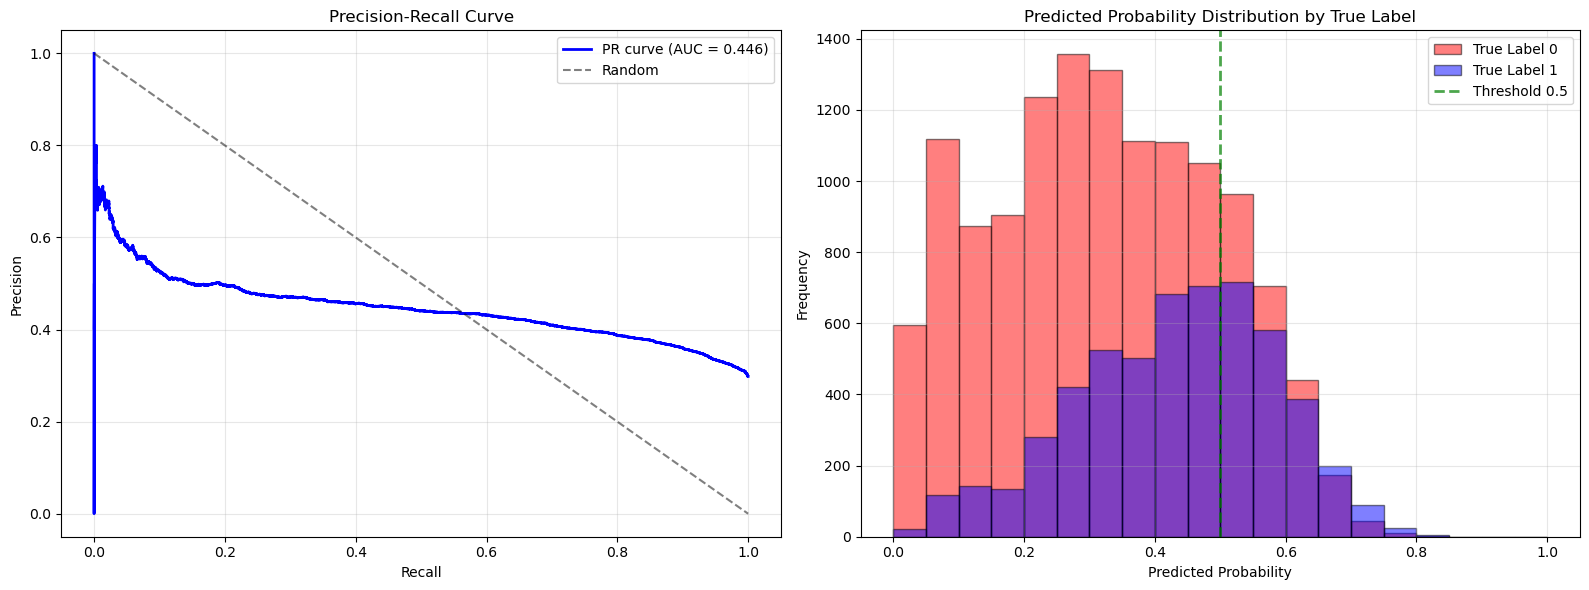

In [32]:
accuracy = evaluate_model(model, X_test, y_test, show_plots=True)

## 创建策略实例

In [103]:
param_dict['delay_snaps'] = 4

In [104]:
model_path = f"/home/jovyan/work/model/delta_{instrument_id}.pkl"
strategy = StrategyDemo(model_path, param_dict)
print(f"策略已创建: {strategy.name}")

策略已创建: delta_v1_adaptive


## 使用backtesting工具进行回测

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 77 个有数据的交易日
-> 过滤后剩余 23 个有数据的交易日
-> 过滤掉 8 个无数据日期: ['20251206', '20251207', '20251213', '20251214', '20251220', '20251221', '20251227', '20251228']
-> 回测标的: 511090 (20251201 - 20251231)
-> 任务分配: 共 23 天，使用 4 个核心并行计算...


[SpawnPoolWorker-100] 日期 20251225 完成 | 盈亏: -7.20 | 成交: 11次 | 平均持仓: 977.7快照
[SpawnPoolWorker-97] 日期 20251201 完成 | 盈亏: 18.60 | 成交: 8次 | 平均持仓: 1416.1快照
[SpawnPoolWorker-98] 日期 20251209 完成 | 盈亏: -34.60 | 成交: 13次 | 平均持仓: 928.5快照
[SpawnPoolWorker-99] 日期 20251217 完成 | 盈亏: 27.30 | 成交: 9次 | 平均持仓: 1258.2快照
[SpawnPoolWorker-100] 日期 20251226 完成 | 盈亏: -25.30 | 成交: 16次 | 平均持仓: 680.5快照
[SpawnPoolWorker-97] 日期 20251202 完成 | 盈亏: 42.50 | 成交: 6次 | 平均持仓: 1690.7快照
[SpawnPoolWorker-98] 日期 20251210 完成 | 盈亏: -8.40 | 成交: 10次 | 平均持仓: 1190.0快照
[SpawnPoolWorker-99] 日期 20251218 完成 | 盈亏: 43.50 | 成交: 7次 | 平均持仓: 1643.1快照
[SpawnPoolWorker-100] 日期 20251229 完成 | 盈亏: 16.30 | 成交: 7次 | 平均持仓: 1646.1快照
[SpawnPoolWorker-97] 日期 20251203 完成 | 盈亏: 38.20 | 成交: 7次 | 平均持仓: 1595.1快照
[SpawnPoolWorker-98] 日期 20251211 完成 | 盈亏: -19.40 | 成交: 13次 | 平均持仓: 905.5快照
[SpawnPoolWorker-99] 日期 20251219 完成 | 盈亏: 25.80 | 成交: 9次 | 平均持仓: 1274.9快照
[SpawnPoolWorker-100] 日期 20251230 完成 | 盈亏: 34.90 | 成交: 8次 | 平均持仓: 1545.1快照
[SpawnPoolWorker-99] 日期 202512

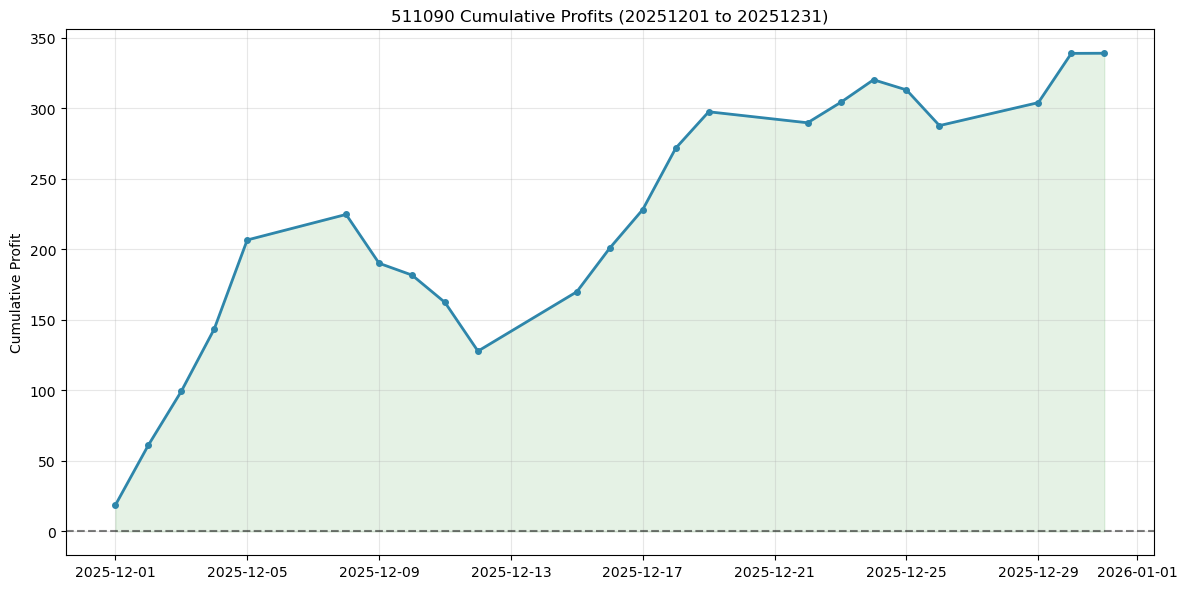


并行回测结果汇总:


{'测试天数': 23,
 '累计总盈亏': np.float64(339.0),
 '总成交次数': 215,
 '日均盈亏': np.float64(14.74),
 '胜率(天)%': 69.57,
 '盈亏比(日均)': np.float64(1.52),
 '最大单日盈利': 63.1,
 '最大单日亏损': -34.6,
 '每笔交易平均盈利': np.float64(1.58),
 '加权平均持仓时间(快照)': np.float64(1181.27)}

In [105]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20251201",
    end_ymd="20251231",
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4
)


print("\n并行回测结果汇总:")
backtest_summary(result_df)

In [45]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(result_df)

,trade_ymd,profits,trades,avg_holding_ticks,trade_date
0,20251201,1.4,8,1312.38,2025-12-01
1,20251202,0.6,11,994.73,2025-12-02
2,20251203,-0.2,12,945.08,2025-12-03
3,20251204,0.8,10,1013.70,2025-12-04
4,20251205,-2.6,11,1042.91,2025-12-05
5,20251208,-5.9,15,788.27,2025-12-08
6,20251209,3.8,7,1765.29,2025-12-09
7,20251210,1.8,9,1368.67,2025-12-10
8,20251211,0.9,12,976.00,2025-12-11
9,20251212,1.4,9,1349.56,2025-12-12


## 延迟回测结果

## 保存回测结果

In [41]:
# 导入结果保存工具
from tools.result_saver import save_backtest_results

# 保存回测结果

result_dir = save_backtest_results(
    param_dict=param_dict,
    summary=summary,
    result_df=result_df
)

print(f"回测结果已保存到: {result_dir}")
print("文件夹包含以下文件:")
import os
for file in os.listdir(result_dir):
    print(f"  - {file}")

保存回测结果到: /home/jovyan/work/tactics_demo/backtest_result/518880_delta_v1_adaptive_20260417_043438
回测结果已保存到: /home/jovyan/work/tactics_demo/backtest_result/518880_delta_v1_adaptive_20260417_043438
文件夹包含以下文件:
  - summary.json
  - daily_results.pkl
  - parameters.json
  - daily_results.csv
  - README.md


In [ ]:
from tools import delete_backtest_results_by_date, delete_backtest_results_by_instrument_date
delete_backtest_results_by_date("20260413", dry_run=True)
deleted = delete_backtest_results_by_instrument_date("518880", "20260414", dry_run=False)


[DRY RUN] 总共将删除 0 个文件夹
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_025053
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_042231
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_011936
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_061311

总共删除了 4 个文件夹


## 单日回测观察

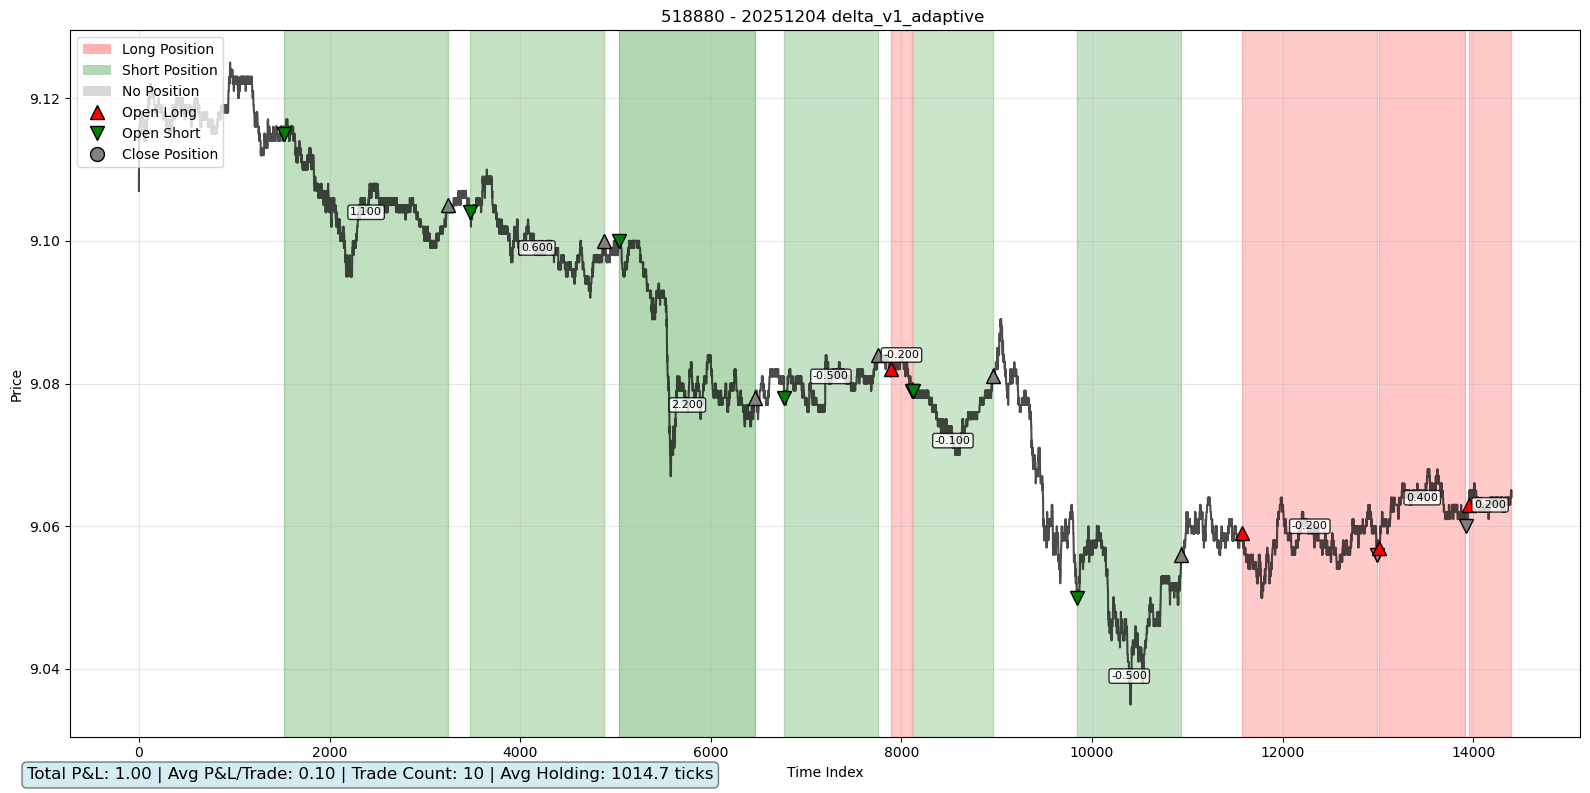

In [40]:
from single_day_backtest import single_day_backtest,plot_delta_history
strategy = StrategyDemo(model_path, param_dict)
hh = single_day_backtest(instrument_id,'20251204',StrategyDemo,model_path,param_dict,official = False)

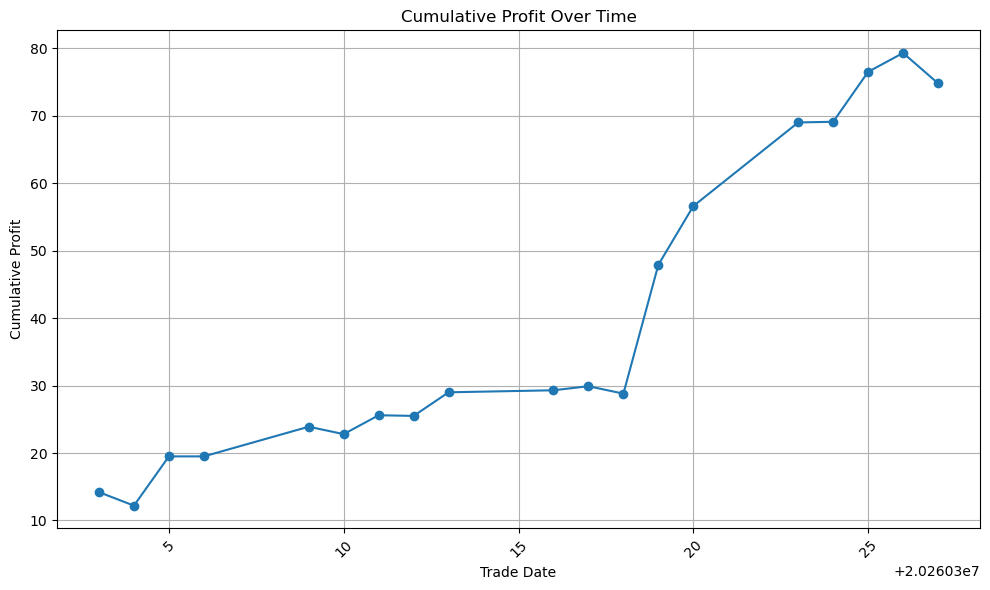

In [ ]:
summary = pd.read_csv('/home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_084832/daily_results.csv')
# plot cumulative profits

summary['cumulative_profit'] = summary['profits'].cumsum()
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(summary['trade_ymd'], summary['cumulative_profit'], marker='o')
plt.title('Cumulative Profit Over Time')
plt.xlabel('Trade Date')
plt.ylabel('Cumulative Profit')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()
